### Experiment with anthropic claude 3 Haiku

In [4]:
import sys
import os
sys.path.append(os.path.abspath('../libs'))

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import prompts as prompts
from exp_utils import classify_dataset_anthropic, evaluate_experiment
from anthropic_lib import call_anthropic
from tqdm import tqdm
import json
import re


/Users/eduardosardenbergtavares1/Documents/PUC-Rio/Telemidia/Smart-Contract-LLM-Evaluation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Define model name
MODEL_NAME = "claude-3-opus-20240229"

### Dataset load

In [6]:
# Load ground truth bug locations
with open("../../../Datasets/bugLocationDappScan.json", "r") as f:
    bug_locations = json.load(f)

In [ ]:
def normalize_path(path):
    if isinstance(path, str):
        return path.replace('\\', '/').replace('./', '').replace('.\\', '')
    return path

bugloc_dict = {
    normalize_path(item['file']): normalize_path(item['location'])
    for item in bug_locations
}


# Load the dataset and convert to appropriate data types
csv_path = "../../../Datasets/dw.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset = df.reset_index(drop=True)
#subset.head()

#### Zero-shot Prompting

In [ ]:
results_df = classify_dataset_anthropic(subset, prompts.create_zeroshot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [5]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])
#print("Taxonomia extraída e formatada:\n", taxonomia)

##### Classificação multiclasse usando taxonomia

In [6]:
csv_path = "../../../Datasets/dw_bug.csv"
#csv_path = "../../../Datasets/dw.csv"

df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [7]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [8]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_anthropic(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [9]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

Classificando arquivos: 100%|███████████████████████████| 200/200 [25:31<00:00,  7.66s/it]


Classificação concluída.


,id,file_path,file_name,true_label,llm_label
0,0,DAppSCAN-main/DAppSCAN-source/contracts/QuillA...,ERC20Permit.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
1,1,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
2,2,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
3,3,DAppSCAN-main/DAppSCAN-source/contracts/openze...,HackerGold.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow
4,4,DAppSCAN-main/DAppSCAN-source/contracts/PeckSh...,UserConfiguration.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow



Resultados da Classificação Multiclasse:
=== Métricas Detalhadas ===

Métricas (micro):
Precisão: 0.855
Recall: 0.855
F1-Score: 0.855

Métricas (macro):
Precisão: 0.813
Recall: 0.842
F1-Score: 0.817

Métricas (weighted):
Precisão: 0.914
Recall: 0.855
F1-Score: 0.871


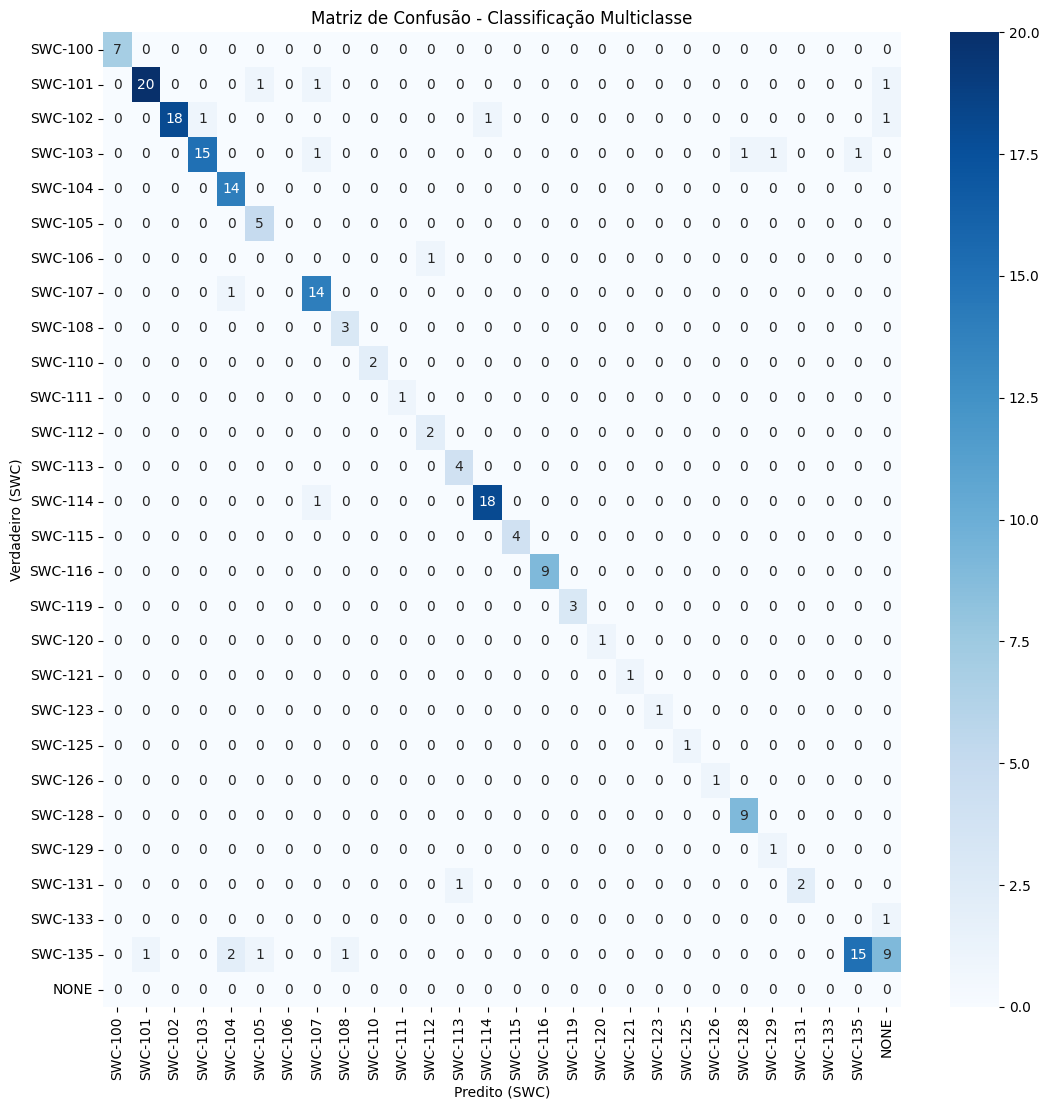

In [10]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [ ]:
multiclass_results_df['true_label'].value_counts()


true_label
SWC-135-Code With No Effects                                       29
SWC-101-Integer Overflow and Underflow                             23
SWC-102-Outdated Compiler Version                                  21
SWC-114-Transaction Order Dependence                               19
SWC-103-Floating Pragma                                            19
SWC-107-Reentrancy                                                 15
SWC-104-Unchecked Call Return Value                                14
SWC-116-Block values as a proxy for time                            9
SWC-128-DoS With Block Gas Limit                                    9
SWC-100-Function Default Visibility                                 7
SWC-105-Unprotected Ether Withdrawal                                5
SWC-113-DoS with Failed Call                                        4
SWC-115-Authorization through tx.origin                             4
SWC-131-Presence of unused variables                                3
SWC-119-S

In [12]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



=== Distribuição das classes preditas (normalizadas) ===



llm_label_swc
NONE       12
SWC-100     7
SWC-101    21
SWC-102    18
SWC-103    16
SWC-104    17
SWC-105     7
SWC-107    17
SWC-108     4
SWC-110     2
SWC-111     1
SWC-112     3
SWC-113     5
SWC-114    19
SWC-115     4
SWC-116     9
SWC-119     3
SWC-120     1
SWC-121     1
SWC-123     1
SWC-125     1
SWC-126     1
SWC-128    10
SWC-129     2
SWC-131     2
SWC-135    16
Name: count, dtype: int64

#### Zero-shot CoT Prompting

In [ ]:
results_df = classify_dataset_anthropic(subset, prompts.create_zeroshot_cot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [13]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])
#print("Taxonomia extraída e formatada:\n", taxonomia)

##### Classificação multiclasse usando taxonomia

In [19]:
csv_path = "../../../Datasets/dw_bug.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [20]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [21]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_cot(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_anthropic(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [22]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

Classificando arquivos: 100%|███████████████████████████| 200/200 [42:05<00:00, 12.63s/it]


Classificação concluída.


,id,file_path,file_name,true_label,llm_label
0,0,DAppSCAN-main/DAppSCAN-source/contracts/QuillA...,ERC20Permit.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
1,1,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
2,2,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,"SWC-103-Floating Pragma, SWC-102-Outdated Comp..."
3,3,DAppSCAN-main/DAppSCAN-source/contracts/openze...,HackerGold.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow
4,4,DAppSCAN-main/DAppSCAN-source/contracts/PeckSh...,UserConfiguration.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow



Resultados da Classificação Multiclasse:
=== Métricas Detalhadas ===

Métricas (micro):
Precisão: 0.900
Recall: 0.900
F1-Score: 0.900

Métricas (macro):
Precisão: 0.844
Recall: 0.874
F1-Score: 0.846

Métricas (weighted):
Precisão: 0.919
Recall: 0.900
F1-Score: 0.899


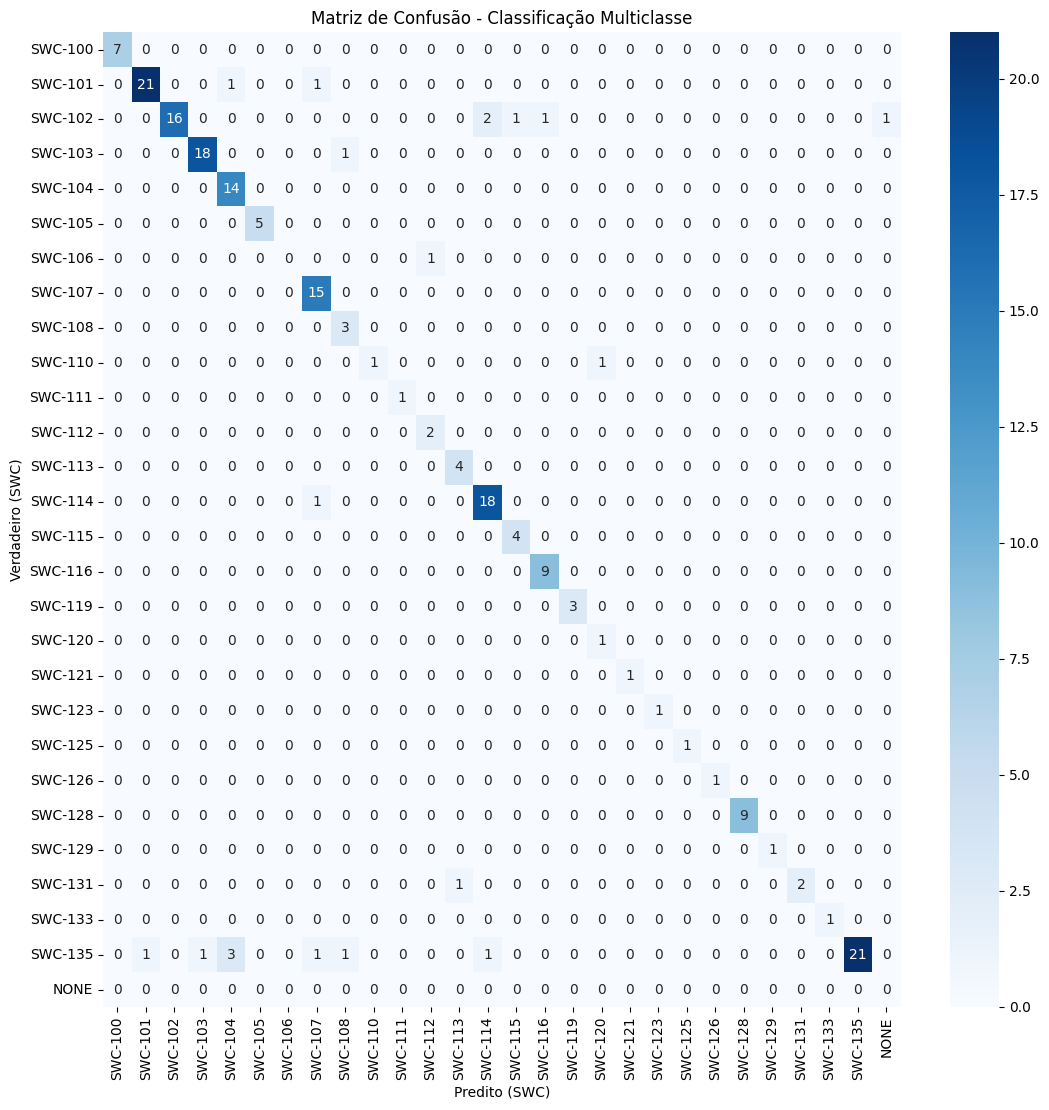

In [23]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [ ]:
multiclass_results_df['true_label'].value_counts()

true_label
SWC-135-Code With No Effects                                       29
SWC-101-Integer Overflow and Underflow                             23
SWC-102-Outdated Compiler Version                                  21
SWC-114-Transaction Order Dependence                               19
SWC-103-Floating Pragma                                            19
SWC-107-Reentrancy                                                 15
SWC-104-Unchecked Call Return Value                                14
SWC-116-Block values as a proxy for time                            9
SWC-128-DoS With Block Gas Limit                                    9
SWC-100-Function Default Visibility                                 7
SWC-105-Unprotected Ether Withdrawal                                5
SWC-113-DoS with Failed Call                                        4
SWC-115-Authorization through tx.origin                             4
SWC-131-Presence of unused variables                                3
SWC-119-S

In [25]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



=== Distribuição das classes preditas (normalizadas) ===



llm_label_swc
NONE        1
SWC-100     7
SWC-101    22
SWC-102    16
SWC-103    19
SWC-104    18
SWC-105     5
SWC-107    18
SWC-108     5
SWC-110     1
SWC-111     1
SWC-112     3
SWC-113     5
SWC-114    21
SWC-115     5
SWC-116    10
SWC-119     3
SWC-120     2
SWC-121     1
SWC-123     1
SWC-125     1
SWC-126     1
SWC-128     9
SWC-129     1
SWC-131     2
SWC-133     1
SWC-135    21
Name: count, dtype: int64

#### Zero-shot ToT Prompting

In [ ]:
results_df = classify_dataset_anthropic(subset, prompts.create_zeroshot_tot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [8]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])

##### Classificação multiclasse usando taxonomia

In [9]:
csv_path = "../../../Datasets/dw_bug.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [10]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [11]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_tot(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_anthropic(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [ ]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

In [ ]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [ ]:
multiclass_results_df['true_label'].value_counts()


In [ ]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



In [ ]:
def classify_multiclass_get_examples(dataset, taxonomia, MODEL_NAME):
    examples = {
        "FN": None,
        "MISCLASS": None,
        "CORRECT": None
    }

    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Buscando exemplos", ncols=90):
        # Para quando já tiver todos
        if all(v is not None for v in examples.values()):
            break

        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'

        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_tot(full_path, file_name, taxonomia)

        try:
            llm_response = call_anthropic(MODEL_NAME, prompt)

            # -------- parsing --------
            bug_type = "NoBug"
            reasoning = ""

            if isinstance(llm_response, str):
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "NoBug").strip()
                    reasoning = response_json.get("reasoning", "")
                except json.JSONDecodeError:
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    reasoning = llm_response

            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "NoBug")
                reasoning = llm_response.get("reasoning", "")

            # -------- identifica cenário --------
            
            if bug_type != true_category:
                scenario = "MISCLASS"
            elif bug_type == true_category:
                scenario = "CORRECT"
            else:
                scenario = "FN" 

            # -------- salva só o primeiro de cada --------
            if examples[scenario] is None:
                examples[scenario] = {
                    "id": idx,
                    "file_name": file_name,
                    "file_path": file_path,
                    "true_label": true_category,
                    "llm_label": bug_type,
                    "reasoning": reasoning,
                    "raw_response": llm_response
                }

                print(f"\n✅ Exemplo encontrado: {scenario}")
                print(f"Arquivo: {file_name}")
                print(f"True bug: {true_category}")
                print(f"LLM bug: {bug_type}")

                print("\n📦 JSON COMPLETO retornado pela LLM:")
                print(llm_response)
                print("-" * 80)

        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")

    return examples


In [17]:
csv_path = "../../../Datasets/dw.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)


examples = classify_multiclass_get_examples(
    subset_bug,
    taxonomia,
    MODEL_NAME
)


Buscando exemplos:   1%|▏                                 | 1/177 [00:12<36:15, 12.36s/it]


✅ Exemplo encontrado: MISCLASS
Arquivo: bbi.sol
True bug: SWC-101-Integer Overflow and Underflow
LLM bug: SWC-105-Unprotected Ether Withdrawal

📦 JSON COMPLETO retornado pela LLM:
{
    "has_error": true,
    "location": "223, 243",
    "reasoning_paths": [
        {
            "path": "Check for integer overflow/underflow vulnerabilities",
            "analysis": "Line 223 uses SafeMath to prevent integer overflow, no issue found."
        },
        {
            "path": "Look for unprotected ether withdrawal",
            "analysis": "Fallback function on lines 243-245 allows anyone to call buyBBITokens and withdraw ether."
        },
        {
            "path": "Analyze access control on sensitive functions",
            "analysis": "buyBBITokens has no access control, allowing anyone to call it."
        },
        {
            "path": "Verify proper use of require statements",
            "analysis": "buyBBITokens has require checks for invalid conditions, no issues found."


Buscando exemplos:   1%|▍                                 | 2/177 [00:25<36:58, 12.68s/it]


✅ Exemplo encontrado: CORRECT
Arquivo: xMPH.sol
True bug: SWC-104-Unchecked Call Return Value
LLM bug: SWC-104-Unchecked Call Return Value

📦 JSON COMPLETO retornado pela LLM:
{
    "has_error": true,
    "location": 178,
    "reasoning_paths": [
        {
            "path": "Unchecked return value of transferFrom() call",
            "analysis": "The return value of mph.transferFrom() is not checked, which may lead to unexpected behavior."
        },
        {
            "path": "Unchecked return value of transfer() call",
            "analysis": "The return value of mph.transfer() is not checked, which may lead to unexpected behavior."
        },
        {
            "path": "Multiple instances of unchecked return values",
            "analysis": "The code has multiple instances of unchecked return values for ERC20 token transfers."
        },
        {
            "path": "Potential loss of funds",
            "analysis": "If the token transfers fail silently, it may lead to los

Buscando exemplos:  46%|███████████████▎                 | 82/177 [17:31<20:17, 12.82s/it]


KeyboardInterrupt: 

In [ ]:
def classify_multiclass_get_examples(dataset, taxonomia, MODEL_NAME):
    examples = {
        "FN": None,
        "MISCLASS": None,
        "CORRECT": None
    }

    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Buscando exemplos", ncols=90):
        # Para quando já tiver todos
        if all(v is not None for v in examples.values()):
            break

        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'

        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_cot(full_path, file_name, taxonomia)

        try:
            llm_response = call_anthropic(MODEL_NAME, prompt)

            # -------- parsing --------
            bug_type = "NoBug"
            reasoning = ""

            if isinstance(llm_response, str):
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "NoBug").strip()
                    reasoning = response_json.get("reasoning", "")
                except json.JSONDecodeError:
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    reasoning = llm_response

            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "NoBug")
                reasoning = llm_response.get("reasoning", "")

            # -------- identifica cenário --------
            if bug_type != true_category:
                scenario = "MISCLASS"
            elif bug_type == true_category:
                scenario = "CORRECT"
            else:
                scenario = "FN" 

            # -------- salva só o primeiro de cada --------
            if examples[scenario] is None:
                examples[scenario] = {
                    "id": idx,
                    "file_name": file_name,
                    "file_path": file_path,
                    "true_label": true_category,
                    "llm_label": bug_type,
                    "reasoning": reasoning,
                    "raw_response": llm_response
                }

                print(f"\n✅ Exemplo encontrado: {scenario}")
                print(f"Arquivo: {file_name}")
                print(f"True bug: {true_category}")
                print(f"LLM bug: {bug_type}")

                print("\n📦 JSON COMPLETO retornado pela LLM:")
                print(llm_response)
                print("-" * 80)

        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")

    return examples


In [20]:
csv_path = "../../../Datasets/dw_bug.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)


examples = classify_multiclass_get_examples(
    subset_bug,
    taxonomia,
    MODEL_NAME
)


Buscando exemplos:   0%|                                          | 0/200 [00:00<?, ?it/s]

Buscando exemplos:   0%|▏                                 | 1/200 [00:10<33:28, 10.09s/it]


✅ Exemplo encontrado: CORRECT
Arquivo: ERC20Permit.sol
True bug: SWC-114-Transaction Order Dependence
LLM bug: SWC-114-Transaction Order Dependence

📦 JSON COMPLETO retornado pela LLM:
{
    "has_error": true,
    "bug_type": "SWC-114-Transaction Order Dependence",
    "location": 53,
    "reasoning": "1. The `permit` function allows a token holder to approve a spender to spend a certain amount of tokens on their behalf by providing a signature.\n2. The function checks if the deadline has passed and the signature is valid.\n3. If the checks pass, it increments the nonce for the token holder to prevent replay attacks.\n4. However, after incrementing the nonce, it calls the `_approve` function to set the allowance for the spender.\n5. This introduces a potential transaction order dependence vulnerability.\n6. If the spender is able to front-run the `permit` transaction with a call to `transferFrom`, they can spend the approved amount before the nonce is incremented.\n7. This can lead to

Buscando exemplos:   2%|▌                                 | 3/200 [00:31<34:24, 10.48s/it]


✅ Exemplo encontrado: MISCLASS
Arquivo: AccessControl.sol
True bug: SWC-103-Floating Pragma
LLM bug: SWC-103-Floating Pragma, SWC-102-Outdated Compiler Version

📦 JSON COMPLETO retornado pela LLM:
{
    "has_error": true,
    "bug_type": "SWC-103-Floating Pragma, SWC-102-Outdated Compiler Version",
    "location": 4,
    "reasoning": "Step 1: Check the pragma directive. The contract uses a floating pragma ^0.6.0, which allows for versions 0.6.0 and above. This can lead to unexpected behavior if the contract is compiled with a different compiler version. It's best to use a fixed pragma version to ensure consistent behavior.

Step 2: Check if the compiler version used is outdated. Solidity 0.6.0 is an older version and it's recommended to use the latest stable version for better security and performance.

Step 3: Scan through the rest of the code. No other issues from the provided taxonomy are found.

In summary, the contract has two issues:
1. SWC-103-Floating Pragma: The contract uses

Buscando exemplos: 100%|████████████████████████████████| 200/200 [40:18<00:00, 12.09s/it]
